# EDP quickstart guide

The Environmental Data Pipeline (EDP) allows user to obtain a comprehensive set of environmental features for a set of user-specified geographic locations, in an easy to use Python interface. This notebook serves as a high-level introduction to new users of the API, including key methods and structure of data inputs and outputs.

The library currently supports data extraction and processing from datasets stored on [Google Earth Engine](https://earthengine.google.com/) (GEE) and from raster data stored locally.

## Installation

For a released package:

```bash
pip install envoi
```

For local development from this repository:

```bash
conda activate eddp
python -m pip install -e '.[dev]'
```

This notebook assumes the package is already importable in the current kernel.

In [ ]:
# Import required packages
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
import rasterio

from envoi import extract, list_reducers
from envoi.auth import init_gee

%load_ext jupyter_black

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black


## Core pattern usage

The main entrypoint of the library is the `extract` method, with the following call pattern: `extract(df, config, catalog, output_dir)`.

Here, `df` is a table of input locations with at least `id`, `lat`, and `lon`. The `config` object describes which feature datasets to use and what kind of output to create. The `catalog` tells the library where those datasets live, either in GEE or as local files on disk. Finally, `output_dir` is where the generated outputs are written.

The library writes results to disk rather than returning dataframes in memory. For tabular outputs, this means a main CSV together with a quality metrics CSV and a metadata JSON. For raster outputs, this means one GeoTIFF tile per location and feature together with a metadata JSON.


## Contents of this demo

Example 1 is the best place to start if you want tabular summaries from a dataset on Google Earth Engine (GEE). Example 2 shows how to export raster tiles instead. Example 3 uses the same overall workflow with a local raster file, and Example 4 shows how the same call structure extends to multiple datasets and multiple source types. Example 5 illustrates how to get data with a temporal dimension from GEE.


## Enabling Google Earth Engine access

The library ships with a number of built-in API endpoints for GEE (the 'catalog'), which lets the user process and download these data without having detailed knowledge of how the underlying GEE API works.

To access data from GEE, you need to set up a Google Cloud project and a service account, then download the service account JSON key from the Cloud Console. See the official guides for [creating and managing service accounts](https://cloud.google.com/iam/docs/service-account-overview) and [using service accounts with Earth Engine](https://developers.google.com/earth-engine/guides/service_account).

`init_gee()` accepts the standard Google-issued service account JSON directly. When called with no path it looks in three places, in order:

1. `$ENVOI_EE_CREDENTIALS` environment variable
2. `~/.config/envoi/ee_credentials.json`
3. `./credentials/ee_credentials.json` (relative to the current working directory)

For this demo, drop the JSON at `../credentials/ee_credentials.json` and the helper below will pick it up automatically. To use a different location, pass `credentials_path=...` or set the env var.

In [ ]:
# Initialize the GEE module and authenticate user credentials
init_gee(credentials_path="../credentials/ee_credentials.json")

## Input data structure

The API expects a table with at least the following fields as input:

- `id`: A site or location id, e.g. a sampling location.
- `lat`, `lon`: Coordinates in a valid CRS format. 

The input can be a CSV file, a pandas dataframe, or a Python dictionary.

If coordinates are not provided in WGS-84 / EPSG:4326 format, they will be converted to this global format before processing.

For obtaining data that has a temporal dimension, a `date` column is also needed. An example of this basic data structure is show below, using the `sample_data.csv` file in this folder.

In [36]:
locations = pd.read_csv(Path("data/input/sample_data.csv"))
locations.head()

,id,lat,lon,date
0,T2T1DJ,62.976878,18.026823,2020-06-01
1,T6WPKD,62.981296,18.030991,2020-06-01
2,TCSZX1,62.976671,18.021154,2020-06-01
3,TG4NHB,62.976843,18.030649,2020-06-01
4,TVCC3Y,62.976773,18.016718,2020-06-01


## Example 1: Getting tabular data from Google Earth Engine

In this example, we fetch elevation data from the [Copernicus DEM GLO-30: Global 30m Digital Elevation Model](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_DEM_GLO30) and output tabular data (`kind: "tabular"`) as a CSV file. We calculate the mean and standard deviation inside each 500 m sampling window centered on the coordinate, which is specified through `reducers: ["mean", "std"]`.

In [ ]:
# The config specifies which dataset to obtain and relevant settings
example_1_config = {
    "batch_id": "tabular_demo",
    "datasets": ["dem_glo30"],
    "settings": {
        "output_type": "tabular",
        "statistics": ["mean", "std"],
        "window_size_m": 500,
        "output_file_format": "csv",
    },
}
output_dir = "data/example_1"

# Call the extractor with the locations dataframe and config as inputs
extract(df=locations, config=example_1_config, output_dir=output_dir, catalog="../configs/ee_catalog.yml")

Let's visualize the outputs of the call we just made. For tabular data, the naming pattern of each output column is `<dataset name>_<statistic>_<window size>`.

In [62]:
example_1_output = pd.read_csv(f"{output_dir}/tabular_demo.csv")
example_1_output.head()

,id,lat,lon,date,dem_glo30_mean_500m,dem_glo30_std_500m
0,T2T1DJ,62.976878,18.026823,2020-06-01,122.009474,13.262500
1,T6WPKD,62.981296,18.030991,2020-06-01,148.341811,23.370105
2,TCSZX1,62.976671,18.021154,2020-06-01,109.930124,10.498873
3,TG4NHB,62.976843,18.030649,2020-06-01,130.045247,15.927184
4,TVCC3Y,62.976773,18.016718,2020-06-01,104.356706,9.558007


### Available spatial statistics and calculation assumptions

**TODO**: Need to confirm this logic for GEE, and ideally ensure consistency between GEE and local.

The number of pixels in the source data covered by each sampling window will depend on its resolution, the window size, and the exact coordinates of each point. Square windows are always used (for consistency with the image-based workflow) and every touched pixel - not only those that are fully covered - are included in the statistics calculations.

For tabular data outputs, use `list_reducers()` to see which spatial statistics are available (for continuous features). These are the statistics calculated over the pixel values in each window.

In [63]:
# Get list of available spatial statistics
list_reducers()

['count',
 'max',
 'mean',
 'median',
 'min',
 'q05',
 'q10',
 'q25',
 'q50',
 'q75',
 'q90',
 'q95',
 'std',
 'sum',
 'var']

## Example 2: Getting data as images

For image-based downstream workflows, `kind: "raster"` exports one GeoTIFF tile per coordinate location, dataset, and window size (eseentially a cut-out of the raster data being processed). If there are multiple features (bands) requested for a certain dataset, these are stored as bands in the GeoTIFF tile. 

Here, `window_m: 200` and `resample_m: 25` implies that each window (output tile) will contain 8x8 = 64 pixels (each pixel with its own elevation value). See details about the `resample_m` parameter below.


In [ ]:
# Raster-based config dictionary, with some differences in settings
example_2_config = {
    "batch_id": "raster_demo",
    "datasets": ["dem_glo30"],
    "settings": {
        "output_type": "raster",
        "window_size_m": 200,
        "resample_m": 25,
    },
}
output_dir = "data/example_2"

# Call the extractor
extract(df=locations, config=example_2_config, output_dir=output_dir, catalog="../configs/ee_catalog.yml")

We can view the pixel-wise elevation values of one of the extracted GeoTIFF images below:

Path: data/example_2/raster_demo/dem_glo30/T2T1DJ-dem_glo30.tif
Shape: (8, 8)
CRS: EPSG:32634
Resolution: (25.0, 25.0)


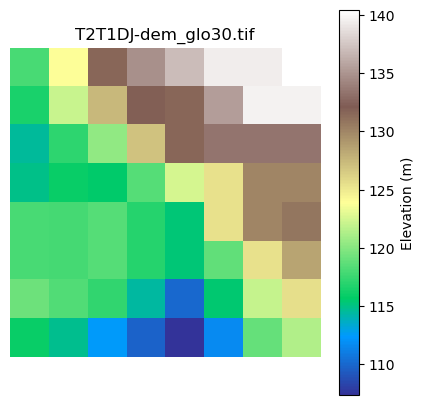

In [65]:
# Collect the tiles
example_2_tiles = sorted(Path(output_dir).glob("raster_demo/dem_glo30/*.tif"))

# Open the TIFF and get metadata
with rasterio.open(example_2_tiles[0]) as src:
    tile = src.read(1)
    print("Path:", example_2_tiles[0])
    print("Shape:", tile.shape)
    print("CRS:", src.crs)
    print("Resolution:", src.res)

# Plot pixels
plt.figure(figsize=(5, 5))
plt.imshow(tile, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title(example_2_tiles[0].name)
plt.axis("off")
plt.show()

### Source and target resolution: Resampling settings

Each source dataset has a native spatial resolution, which is the pixel size in the original data. The optional `resample_m` parameter sets the target pixel size of the exported tiles. If the target resolution is coarser than the source, multiple source pixels are aggregated (averaged) into fewer output pixels. If the target resolution is finer than the source, the output gets more pixels, but those extra pixels are created by resampling (replication) rather than adding new underlying information.

## Example 3: Working with local files on disk

While there are many excellent datasets on GEE, sometimes we want to use data that is only available as local rasters on disk. The same `extract()` interface can be used for those sources as well. Unlike GEE, where there is a built-in catalog of available datasets, the catalog needs to be created by the user. In the example below, we use a local DEM and create the catalog inline. 

In this case the local DEM file contains several bands, so the band(s) can be specified explicitly using the `bands` argument. If this is not given, all bands are returned by default.

- **TODO**: The bands should not be specified in the catalog, that belongs to the config.

In [ ]:
# Add the DEM dataset to the local catalog
local_catalog = {
    "datasets": {
        "dem_local": {
            "data_source": "local",
            "path": "../data/for_testing/dem/TG4NHB-dem.tif",
            "bands": [1, 2],  # BUG: Should not be in catalog, should be in config
        }
    }
}

# Same settings as the previous GEE examples, just different source
example_3_1_config = {
    "batch_id": "local_tabular_demo",
    "datasets": ["dem_local"],
    "settings": {
        "output_type": "tabular",
        "statistics": ["mean", "std"],
        "window_size_m": 500,
        "output_file_format": "csv",
    },
}

local_output_dir = "data/example_3_1"
extract(df=locations, config=example_3_1_config, catalog=local_catalog, output_dir=local_output_dir)
pd.read_csv(f"{local_output_dir}/local_tabular_demo.csv").head()

We can see that the elevation values are very similar to the elevation data from GEE. 

In the same fashion, we can of course extract image data from this local source:

In [ ]:
# Same settings as the previous GEE examples, just different source
example_3_2_config = {
    "batch_id": "local_raster_demo",
    "datasets": ["dem_local"],
    "settings": {
        "output_type": "raster",
        "window_size_m": 200,
        "resample_m": 25,
    },
}

local_output_dir = "data/example_3_2"
extract(df=locations, config=example_3_2_config, catalog=local_catalog, output_dir=local_output_dir)

## Example 4: Multiple datasets, sources and features

It's possible to process multiple datasets in the same call to `extract()`, which can also include a mix of GEE and local raster files. The API automatically routes the calls to the underlying modules based on `source`.

- **TODO**: Should not have to create an entirely new catalog for this. It should combine the default GEE catalog with user defined catalogs / updates.

In [ ]:
example_4_catalog = {
    "datasets": {
        "dem_glo30": {
            "data_source": "earth_engine",
            "path": "COPERNICUS/DEM/GLO30",
            "bands": ["DEM"],  # bands
        },
        "dem_local": {
            "data_source": "local",
            "path": "../data/for_testing/dem/TG4NHB-dem.tif",
            "bands": 1,
        },
    }
}

example_4_config = {
    "batch_id": "multi_source_demo",  # batch_id
    "datasets": ["dem_glo30", "dem_local"],
    "settings": {  # settings
        "output_type": "tabular",  # output_type
        "statistics": ["mean", "std"],  # statistics
        "window_size_m": 500,  # window_size_m
        "output_file_format": "csv",  # output_file_format
    },
}

example_4_output_dir = "data/example_4"
extract(df=locations, config=example_4_config, catalog=example_4_catalog, output_dir=example_4_output_dir)
pd.read_csv(f"{example_4_output_dir}/multi_source_demo.csv").head()

## Example 5: Working with temporal data

Sometimes we might have data for the same location at multiple timepoints. If there is a temporal dimension to the source data as well, we can extract time-specific values of a feature by including a `date` column in the input table. For GEE [ImageCollections](https://developers.google.com/earth-engine/guides/ic_info), the date matching logic is:

- If a `date` is provided, the library matches each sample to the nearest available image date in the collection.
- If the requested date falls outside the collection's available date range, it is clamped to the nearest boundary date.
- If no `date` is provided, the library uses the most recent available image.
- The date decision used for each sample is recorded in the quality control output through `image_date_used`, `date_clamped`, and `date_source`.

For regular GEE image assets, there is no temporal matching logic: they are treated as static images, so a `date` column does not change which data are read. For local raster sources, there is currently no temporal matching logic either.

**TODO**: Demo this using an appropriate dataset

## Categorical vs continuous data

In the examples above, we've extracted continuous (or discrete) feature data and associated spatial statistics. The GEE and local APIs also support binary or categorical data from datasets that contain such bands, e.g. land use-land cover datasets. For categorical rasters, point sampling is currently the main supported tabular workflow. Window-based tabular summaries are primarily intended for continuous variables.

## Quality metrics and metadata

The call to `extract()` also generates a CSV with quality control (QC) metrics that can be useful to diagnose potential issues:

- `in_extent (bool)`: whether the sample location or sampling window overlaps the available data source.
- `n_pixels (int)`: the number of pixels included in the sampled result.
- `had_nodata (bool)`: whether nodata or missing values were encountered inside the sampled window.
- `coverage_pct (float)`: the percentage of sampled pixels that contained valid data.
- `image_date_used (datetime)`: for temporal GEE collections, the image date actually used for that sample.
- `date_clamped (bool)`: whether the requested sample date had to be clamped to the nearest available date in the collection.
- `date_source (str)`: how the image date was chosen, for example `nearest_to_sample`, `clamped_to_nearest`, or `most_recent_no_date`.
- `region_crs (str)`: the CRS used for the sampled region or exported tile geometry.

In [57]:
example_1_qc = pd.read_csv("data/example_1/tabular_demo_qc.csv")
example_1_qc.head()

,id,lat,lon,date,dem_glo30_in_extent_500m,dem_glo30_n_pixels_500m,dem_glo30_had_nodata_500m,dem_glo30_coverage_pct_500m,dem_glo30_image_date_used_500m,dem_glo30_date_clamped_500m,dem_glo30_date_source_500m,dem_glo30_region_crs_500m
0,T2T1DJ,62.976878,18.026823,2020-06-01,True,1,False,100.0,2006-01-01,True,clamped_to_nearest,EPSG:32634
1,T6WPKD,62.981296,18.030991,2020-06-01,True,1,False,100.0,2006-01-01,True,clamped_to_nearest,EPSG:32634
2,TCSZX1,62.976671,18.021154,2020-06-01,True,1,False,100.0,2006-01-01,True,clamped_to_nearest,EPSG:32634
3,TG4NHB,62.976843,18.030649,2020-06-01,True,1,False,100.0,2006-01-01,True,clamped_to_nearest,EPSG:32634
4,TVCC3Y,62.976773,18.016718,2020-06-01,True,1,False,100.0,2006-01-01,True,clamped_to_nearest,EPSG:32634


The metadata JSON records the run settings, source dataset details, and summary quality information.

In [56]:
with open("data/example_1/tabular_demo_metadata.json") as f:
    example_1_metadata = json.load(f)

print(json.dumps(example_1_metadata, indent=2))

{
  "run": {
    "timestamp": "2026-04-13T09:55:14Z",
    "package_version": "0.1.2",
    "n_points": 6
  },
  "config": {
    "name": "tabular_demo",
    "reducers": [
      "mean",
      "std"
    ],
    "window_m": 500,
    "min_coverage_pct": 80
  },
  "features": {
    "dem_glo30": {
      "source": "earth_engine",
      "path": "COPERNICUS/DEM/GLO30",
      "asset_type": "IMAGE_COLLECTION",
      "native_crs": "EPSG:4326",
      "native_spatial_resolution_m": 30.92,
      "band_names": [
        "DEM"
      ],
      "collection_date_range": [
        "2006-01-01",
        "2006-01-01"
      ]
    }
  },
  "quality": {
    "dem_glo30": {
      "500": {
        "n_zero": 0,
        "n_partial": 0,
        "n_full": 6,
        "total": 6
      }
    }
  },
  "date_info": {
    "dem_glo30": {
      "n_nearest_to_sample": 0,
      "n_clamped_to_nearest": 6,
      "n_most_recent_no_date": 0,
      "image_dates_used": [
        "2006-01-01"
      ]
    }
  }
}


## Updating GEE and local catalogs with new datasets

**TODO**: For handling added GEE datasets and the local catalog, it would be good to have something like the following flow and helper functions

```python
# Define catalog with datasets not part of the standard distribution 
additional_gee_data = {...}

# Use the update helper to add these to the built-in catalog
update_catalog(additional_gee_data, source="gee")

# Similarly, we can store add local data sources to the main catalog 
local_data = {...}
update_catalog(local_data, source="local")
```